In [13]:
import numpy as np

train = np.load("../CNN/data/processed/train.npz")
val = np.load("../CNN/data/processed/val.npz")
test = np.load("../CNN/data/processed/test.npz")


X_train, y_train = train['x'], train['y']
X_val, y_val = val['x'], val['y']
X_test, y_test = test['x'], test['y']

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (45000, 32, 32, 3) (45000,)
Val: (5000, 32, 32, 3) (5000,)
Test: (10000, 32, 32, 3) (10000,)


X_train shape: (45000, 32, 32, 3)
y_train shape: (45000,)


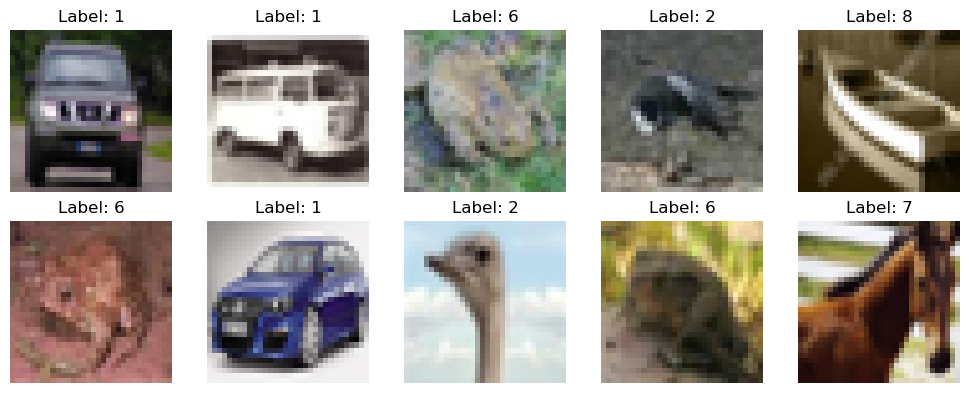

In [4]:
import numpy as np
import matplotlib.pyplot as plt

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

# If data is in (N, 32, 32, 3) format
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i])
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [6]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2" 

In [15]:
# Flatten (32, 32, 3) → (3072,)
X_train = X_train.reshape((X_train.shape[0], -1))
X_val = X_val.reshape((X_val.shape[0], -1))
X_test = X_test.reshape((X_test.shape[0], -1))

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (45000, 3072)
Val: (5000, 3072)
Test: (10000, 3072)


In [17]:
from sklearn.decomposition import PCA

# Reduce to 300 components
pca = PCA(n_components=300)
X_train_pca = pca.fit_transform(X_train)
X_val_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test)

# Combine train + val for final model training later
X_combined = np.concatenate((X_train_pca, X_val_pca), axis=0)
y_combined = np.concatenate((y_train, y_val), axis=0)

print("PCA reduced shapes:")
print("Train PCA:", X_train_pca.shape)
print("Val PCA:", X_val_pca.shape)
print("Test PCA:", X_test_pca.shape)


PCA reduced shapes:
Train PCA: (45000, 300)
Val PCA: (5000, 300)
Test PCA: (10000, 300)


In [18]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelBinarizer

# Create and train baseline model
baseline_model = XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    num_class=10,
    n_estimators=100,
    tree_method='hist'
)
baseline_model.fit(X_train_pca, y_train)

# Evaluate on validation set
y_val_pred = baseline_model.predict(X_val_pca)
y_val_prob = baseline_model.predict_proba(X_val_pca)

# Metrics
acc_base = accuracy_score(y_val, y_val_pred)
f1_base = f1_score(y_val, y_val_pred, average='macro')

lb = LabelBinarizer()
y_val_bin = lb.fit_transform(y_val)
auc_base = roc_auc_score(y_val_bin, y_val_prob, average='macro', multi_class='ovr')

print("Baseline XGBoost Results (Validation Set):")
print("Accuracy:", round(acc_base, 4))
print("F1 Score (macro):", round(f1_base, 4))
print("AUC Score (macro, OVR):", round(auc_base, 4))


Baseline XGBoost Results (Validation Set):
Accuracy: 0.5004
F1 Score (macro): 0.4984
AUC Score (macro, OVR): 0.8814


In [19]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

Classification Report - Baseline XGBoost (Validation Set):

              precision    recall  f1-score   support

    airplane       0.57      0.56      0.57       500
  automobile       0.57      0.57      0.57       500
        bird       0.43      0.40      0.42       500
         cat       0.32      0.31      0.31       500
        deer       0.44      0.39      0.41       500
         dog       0.41      0.41      0.41       500
        frog       0.55      0.60      0.57       500
       horse       0.54      0.52      0.53       500
        ship       0.63      0.67      0.65       500
       truck       0.51      0.58      0.55       500

    accuracy                           0.50      5000
   macro avg       0.50      0.50      0.50      5000
weighted avg       0.50      0.50      0.50      5000



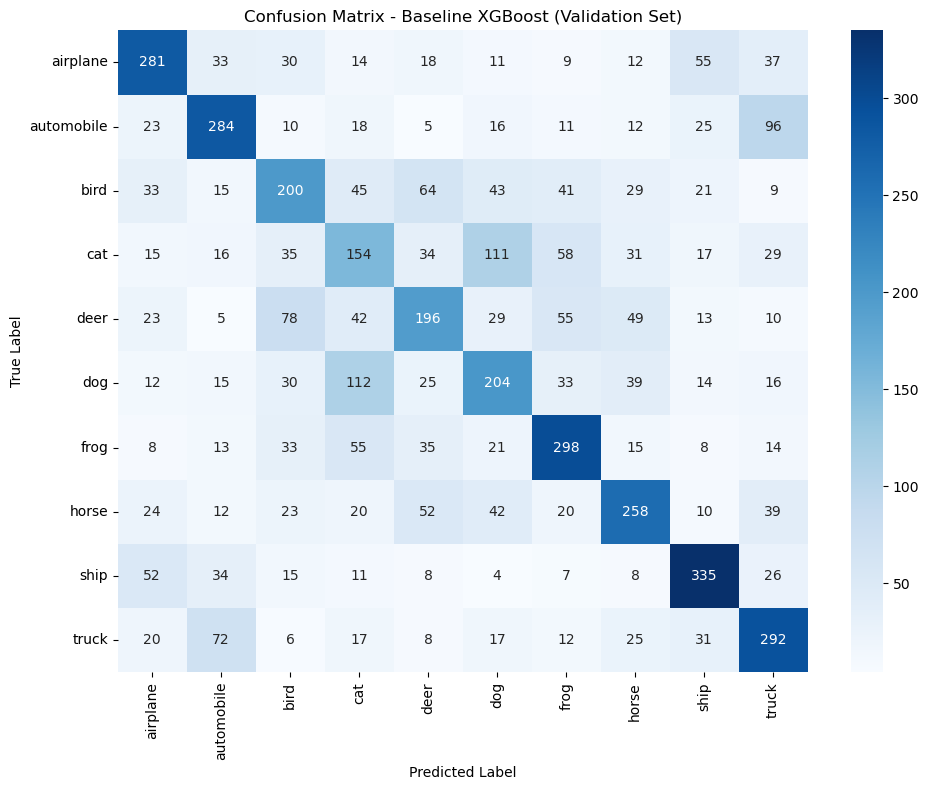

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# Compute confusion matrix
conf_matrix_base = confusion_matrix(y_val, y_val_pred)



# Print detailed per-class metrics
print("Classification Report - Baseline XGBoost (Validation Set):\n")
print(classification_report(y_val, y_val_pred, target_names=class_names))

# Plot it
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_base, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.title("Confusion Matrix - Baseline XGBoost (Validation Set)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [23]:
import os
os.makedirs("outputs/models", exist_ok=True)

In [24]:
import joblib

joblib.dump(baseline_model, "outputs/models/xgb_cifar10_baseline_model.pkl")
print("Baseline model saved to outputs/models/xgb_cifar10_baseline_model.pkl")

Baseline model saved to outputs/models/xgb_cifar10_baseline_model.pkl


In [32]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

# Use GPU training
model = XGBClassifier(
    tree_method='hist',
    device='cuda',   
    objective='multi:softprob',
    eval_metric='mlogloss',
    num_class=10
)

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
    'learning_rate': [0.1, 0.2]
}

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=3,
    verbose=1,
    n_jobs=2  # XGBoost runs on GPU, folds run in parallel on CPU
)

# Fit using only training data
grid_search.fit(X_train_pca, y_train)


Fitting 3 folds for each of 8 candidates, totalling 24 fits


/home/jupyter-shr624/.local/lib/python3.11/site-packages/xgboost/core.py:729: UserWarning: [16:31:30] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
/home/jupyter-shr624/.local/lib/python3.11/site-packages/xgboost/core.py:729: UserWarning: [16:31:30] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
-

GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device='cuda',
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='mlogloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constra...
                                     learning_rate=None, max_bin=None,
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_class=10, ...),
             n_jobs=2,
             param_grid={'learning_rate': [0.1, 0.2], 'max_depth': [3, 5],
                         'n_estimators': [50, 100]},
             scoring='f1_macro', verbose=1)

In [35]:
import joblib

joblib.dump(model, "outputs/models/xgb_cifar10_best_model.pkl")
joblib.dump(pca, "outputs/models/pca_cifar10.pkl")

['outputs/models/pca_cifar10.pkl']

In [41]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelBinarizer
import matplotlib.pyplot as plt
import seaborn as sns


best_model = grid_search.best_estimator_

# Retrain on combined train + val
best_model.fit(X_combined, y_combined)


# Predict using XGBClassifier directly
y_prob = best_model.predict_proba(X_test_pca)
y_pred = best_model.predict(X_test_pca)

# Evaluation metrics
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')

lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test)
auc = roc_auc_score(y_test_bin, y_prob, average='macro', multi_class='ovr')

print("Final Evaluation (Best Model on Test Set):")
print(f"Accuracy: {acc:.4f}")
print(f"F1 Score (macro): {f1:.4f}")
print(f"AUC Score (macro, OvR): {auc:.4f}")



/home/jupyter-shr624/.local/lib/python3.11/site-packages/xgboost/core.py:729: UserWarning: [16:47:56] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Final Evaluation (Best Model on Test Set):
Accuracy: 0.4992
F1 Score (macro): 0.4954
AUC Score (macro, OvR): 0.8799


In [42]:
from sklearn.metrics import classification_report

# CIFAR-10 class names (standard order)
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Classification Report (Fine-Tuned Model on Test Set):")
print(classification_report(y_test, y_pred, target_names=class_names))


Classification Report (Fine-Tuned Model on Test Set):
              precision    recall  f1-score   support

    airplane       0.57      0.57      0.57      1000
  automobile       0.57      0.60      0.59      1000
        bird       0.41      0.35      0.38      1000
         cat       0.33      0.33      0.33      1000
        deer       0.45      0.42      0.43      1000
         dog       0.43      0.36      0.39      1000
        frog       0.53      0.63      0.57      1000
       horse       0.55      0.53      0.54      1000
        ship       0.58      0.66      0.62      1000
       truck       0.53      0.55      0.54      1000

    accuracy                           0.50     10000
   macro avg       0.49      0.50      0.50     10000
weighted avg       0.49      0.50      0.50     10000



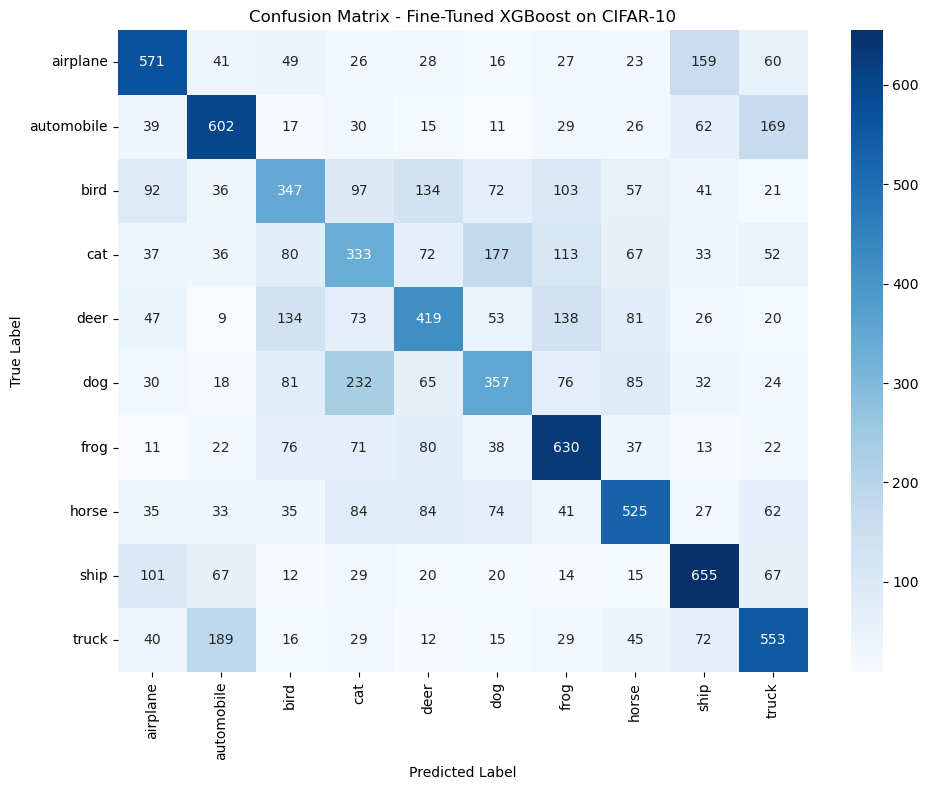

In [44]:
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - Fine-Tuned XGBoost on CIFAR-10")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("outputs/figures/xgb_cifar10_final_confusion_matrix.png", dpi=300)
plt.show()

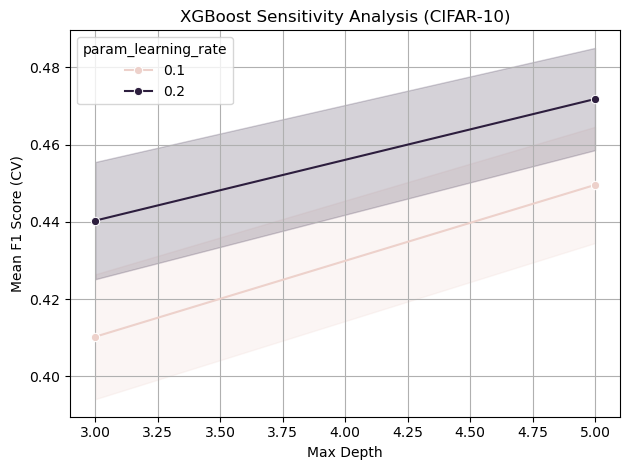

In [45]:
import pandas as pd

# Use GridSearchCV results
results_df = pd.DataFrame(grid_search.cv_results_)

sns.lineplot(
    data=results_df,
    x="param_max_depth",
    y="mean_test_score",
    hue="param_learning_rate",
    marker="o"
)
plt.title("XGBoost Sensitivity Analysis (CIFAR-10)")
plt.xlabel("Max Depth")
plt.ylabel("Mean F1 Score (CV)")
plt.grid(True)
plt.tight_layout()
plt.savefig("outputs/figures/xgb_cifar10_sensitivity_plot.png", dpi=300)
plt.show()
